In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style('whitegrid')



In [ ]:
df = pd.read_csv('/content/startup_funding.csv')

In [ ]:
df.head(10)

,SNo,Date,StartupName,IndustryVertical,SubVertical,CityLocation,InvestorsName,InvestmentType,AmountInUSD,Remarks
0,0,01/08/2017,TouchKin,Technology,Predictive Care Platform,Bangalore,Kae Capital,Private Equity,"1,300,000",NaN
1,1,02/08/2017,Ethinos,Technology,Digital Marketing Agency,Mumbai,Triton Investment Advisors,Private Equity,NaN,NaN
2,2,02/08/2017,Leverage Edu,Consumer Internet,Online platform for Higher Education Services,New Delhi,"Kashyap Deorah, Anand Sankeshwar, Deepak Jain,...",Seed Funding,NaN,NaN
3,3,02/08/2017,Zepo,Consumer Internet,DIY Ecommerce platform,Mumbai,"Kunal Shah, LetsVenture, Anupam Mittal, Hetal ...",Seed Funding,"500,000",NaN
4,4,02/08/2017,Click2Clinic,Consumer Internet,healthcare service aggregator,Hyderabad,"Narottam Thudi, Shireesh Palle",Seed Funding,"850,000",NaN
5,5,01/07/2017,Billion Loans,Consumer Internet,Peer to Peer Lending platform,Bangalore,Reliance Corporate Advisory Services Ltd,Seed Funding,"1,000,000",NaN
6,6,03/07/2017,Ecolibriumenergy,Technology,Energy management solutions provider,Ahmedabad,"Infuse Ventures, JLL",Private Equity,"2,600,000",NaN
7,7,04/07/2017,Droom,eCommerce,Online marketplace for automobiles,Gurgaon,"Asset Management (Asia) Ltd, Digital Garage Inc",Private Equity,"20,000,000",NaN
8,8,05/07/2017,Jumbotail,eCommerce,online marketplace for food and grocery,Bangalore,"Kalaari Capital, Nexus India Capital Advisors",Private Equity,"8,500,000",NaN
9,9,05/07/2017,Moglix,eCommerce,B2B marketplace for Industrial products,Noida,"International Finance Corporation, Rocketship,...",Private Equity,"12,000,000",NaN


In [ ]:
df.columns # Column Names


Index(['SNo', 'Date', 'StartupName', 'IndustryVertical', 'SubVertical',
       'CityLocation', 'InvestorsName', 'InvestmentType', 'AmountInUSD',
       'Remarks'],
      dtype='object')

In [ ]:
df.shape # Shape of Data

(2372, 10)

In [ ]:
df.info() # Data Types & Missing Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372 entries, 0 to 2371
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SNo               2372 non-null   int64 
 1   Date              2372 non-null   object
 2   StartupName       2372 non-null   object
 3   IndustryVertical  2201 non-null   object
 4   SubVertical       1436 non-null   object
 5   CityLocation      2193 non-null   object
 6   InvestorsName     2364 non-null   object
 7   InvestmentType    2371 non-null   object
 8   AmountInUSD       1525 non-null   object
 9   Remarks           419 non-null    object
dtypes: int64(1), object(9)
memory usage: 185.4+ KB


In [ ]:
df.describe()


,SNo
count,2372.000000
mean,1185.500000
std,684.881742
min,0.000000
25%,592.750000
50%,1185.500000
75%,1778.250000
max,2371.000000


In [ ]:
df.isnull().sum()

,0
SNo,0
Date,0
StartupName,0
IndustryVertical,171
SubVertical,936
CityLocation,179
InvestorsName,8
InvestmentType,1
AmountInUSD,847
Remarks,1953


In [ ]:
df['AmountInUSD'] = df['AmountInUSD'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['AmountInUSD'] = pd.to_numeric(df['AmountInUSD'], errors='coerce')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [ ]:
df['CityLocation'].fillna('Unknown', inplace=True)
df['IndustryVertical'].fillna('Unknown', inplace=True)
df['AmountInUSD'] = df['AmountInUSD'].fillna(df['AmountInUSD'].median())

/tmp/ipykernel_1078/2740988053.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CityLocation'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1078/2740988053.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

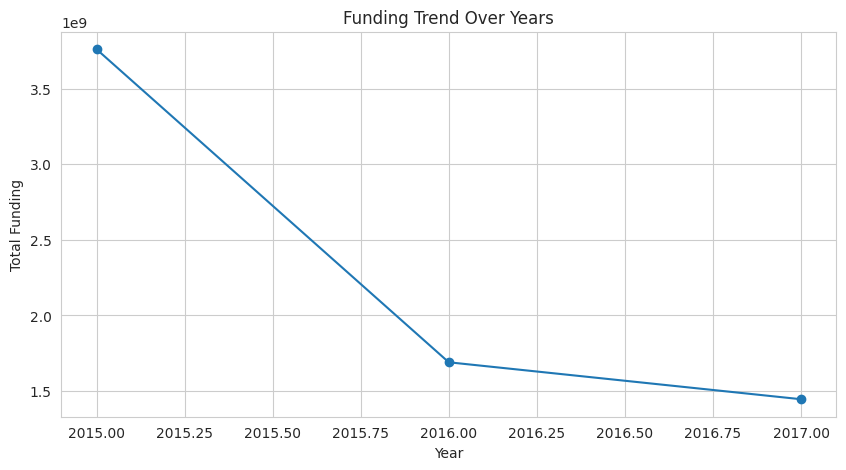

In [ ]:
import numpy as np

# Ensure 'AmountInUSD' is numeric and handle NaNs
df['AmountInUSD'] = pd.to_numeric(df['AmountInUSD'], errors='coerce')

# Calculate median of valid amounts
median_amount = df['AmountInUSD'].median()

# Fill NaNs with median, or 0 if median is NaN (meaning all values are NaN)
if pd.isna(median_amount):
    df['AmountInUSD'] = df['AmountInUSD'].fillna(0)
else:
    df['AmountInUSD'] = df['AmountInUSD'].fillna(median_amount)

# Ensure 'Year' is integer type, filling NaNs if any (shouldn't be if dropna(subset=['Date']) worked)
df['Year'] = df['Year'].fillna(0).astype(int) # Assuming 0 is a reasonable default for missing years

yearly_funding = df.groupby('Year')['AmountInUSD'].sum()

plt.figure(figsize=(10,5))
yearly_funding.plot(marker='o')
plt.title("Funding Trend Over Years")
plt.ylabel("Total Funding")
plt.show()

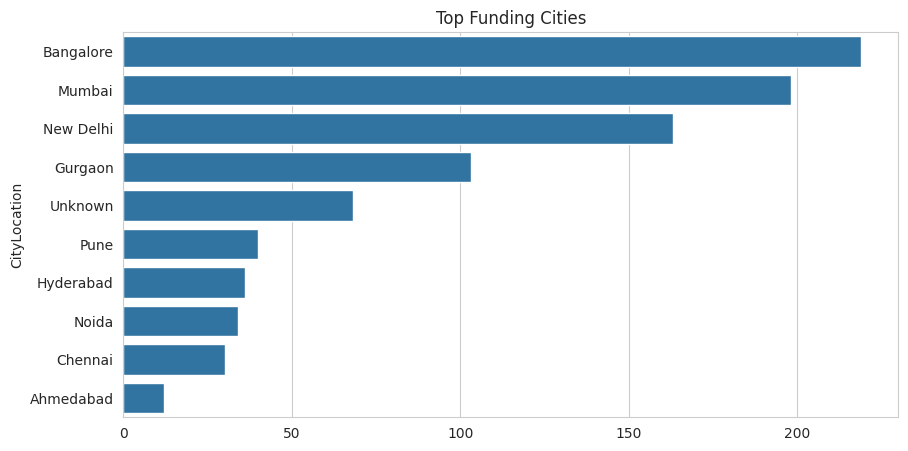

In [ ]:
top_cities = df['CityLocation'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top Funding Cities")
plt.show()

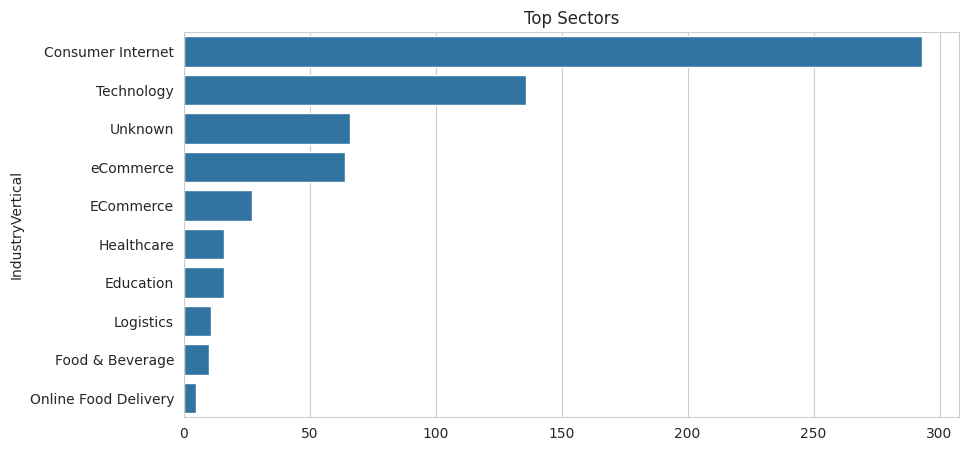

In [ ]:
top_cities = df['IndustryVertical'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top Sectors")
plt.show()

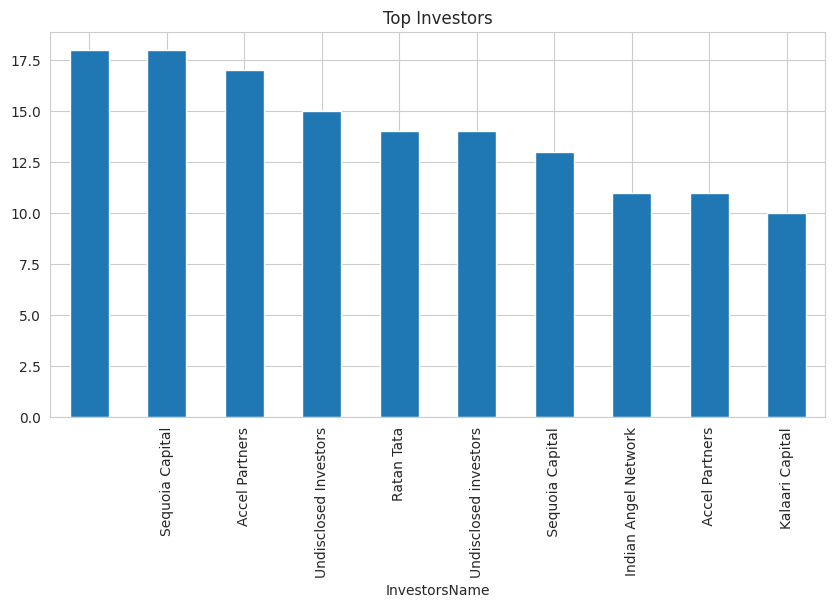

In [ ]:
df['InvestorsName'] = df['InvestorsName'].fillna('Unknown')

investors = df.assign(InvestorsName=df['InvestorsName'].str.split(',')).explode('InvestorsName')

top_investors = investors['InvestorsName'].value_counts().head(10)

top_investors.plot(kind='bar', figsize=(10,5))
plt.title("Top Investors")
plt.show()

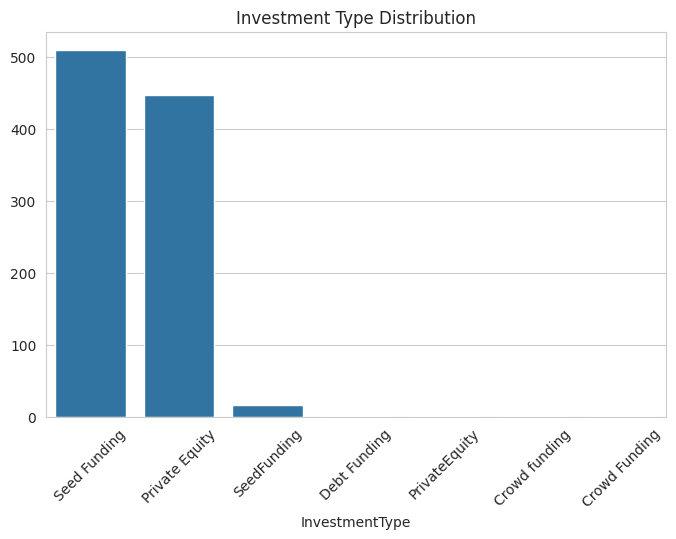

In [ ]:
funding_type = df['InvestmentType'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=funding_type.index, y=funding_type.values)
plt.xticks(rotation=45)
plt.title("Investment Type Distribution")
plt.show()

In [ ]:
df_model = df[['Year', 'Month', 'CityLocation', 'IndustryVertical', 'AmountInUSD']]

df_model = pd.get_dummies(df_model, columns=['CityLocation', 'IndustryVertical'], drop_first=True)


In [ ]:
x = df_model.drop('AmountInUSD', axis=1)
y = df_model['AmountInUSD']

x_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x = df_model.drop('AmountInUSD', axis=1)
y = df_model['AmountInUSD']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

print("Linear Regression R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Linear Regression R2: -0.05262186732698537
RMSE: 32191792.9188336


In [ ]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest R2: -0.07064991978613455
RMSE:  32466293.90302547


In [ ]:
import pickle

with open('random_forest_model.pkl', 'wb') as file:
  pickle.dump(rf, file)

  print("Model download successfully!")

Model download successfully!


In [ ]:
from google.colab import files

files.download('random_forest_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>